# Hypothesis Testing via Segmentation

Segmentation is used to validate behavioral patterns in customers.

Objective:
- Identify distinct customer groups
- Measure revenue contribution
- Analyze risk distribution

Segments represent real-world credit card personas:
- Power Spenders
- Revolvers
- Transactors
- Dormant Customers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("../dataset/processed/credit_card_features.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (10127, 27)


In [5]:
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,VIP_Flag,Ticket_Size,Utilization,Engagement,Portfolio_Yield_Proxy,CLV_Score,Transaction_Velocity
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0,27.238095,0.061224,1.076923,70.040816,1307.428571,3.500000
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0,39.121212,0.104651,0.750000,135.104651,1069.578488,2.750000
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0,94.350000,0.000000,0.555556,0.000000,1048.333333,1.666667
3,Existing Customer,40,F,4,High School,Not_Disclosed,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0,58.550000,0.759734,0.588235,889.648959,1212.146446,1.666667
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0,29.142857,0.000000,1.333333,0.000000,1088.000000,2.333333


# Hypothesis Validation Framework

Each hypothesis will be evaluated using:

Hypothesis → Data Analysis → Result → Conclusion


**Behavioral Segmentation**

In [6]:
def segment_customer(row):

    if row["Total_Trans_Amt"] > 8000 and row["Engagement"] > 8:
        return "Power Spender"

    elif row["Utilization"] > 0.6:
        return "Revolver"

    elif row["Engagement"] > 5 and row["Utilization"] < 0.3:
        return "Transactor"

    else:
        return "Dormant"
    

df["Customer_Segment"] = df.apply(segment_customer, axis=1)

In [7]:
segment_counts = df["Customer_Segment"].value_counts()

print(segment_counts)

Customer_Segment
Dormant          8250
Revolver         1807
Transactor         63
Power Spender       7
Name: count, dtype: int64


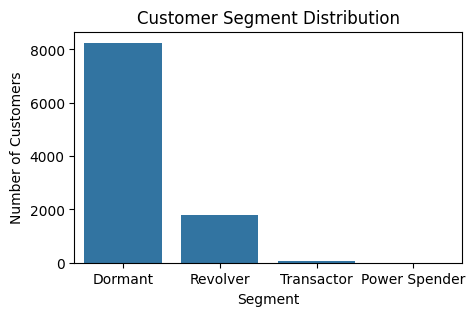

In [8]:
plt.figure(figsize=(5,3))

sns.countplot(data=df, x="Customer_Segment",
              order=segment_counts.index)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

**Average Spend by Segment**

In [9]:
spend_segment = df.groupby("Customer_Segment")["Total_Trans_Amt"].mean().sort_values(ascending=False)

print(spend_segment)

Customer_Segment
Power Spender    16014.285714
Transactor       11708.523810
Dormant           4484.098424
Revolver          3739.143885
Name: Total_Trans_Amt, dtype: float64


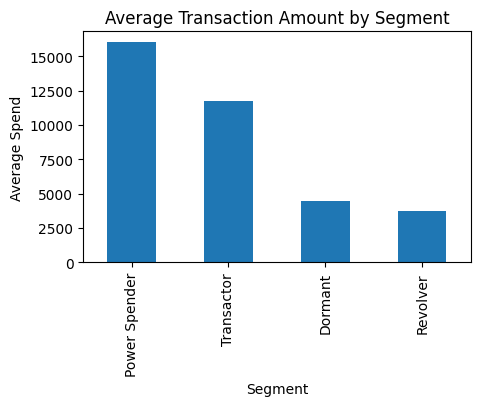

In [10]:
plt.figure(figsize=(5,3))

spend_segment.plot(kind="bar")

plt.title("Average Transaction Amount by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Spend")

plt.show()

**Utilization by Segment**

In [11]:
util_segment = df.groupby("Customer_Segment")["Utilization"].mean().sort_values(ascending=False)

print(util_segment)

Customer_Segment
Revolver         0.737471
Power Spender    0.265452
Dormant          0.174845
Transactor       0.109332
Name: Utilization, dtype: float64


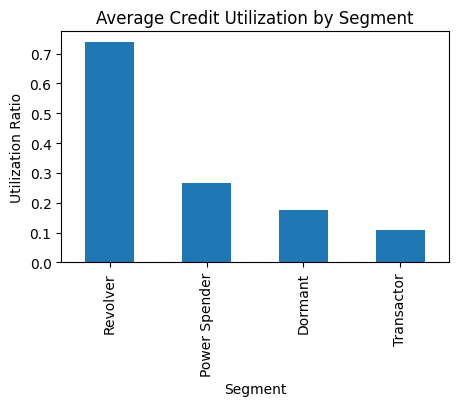

In [12]:
plt.figure(figsize=(5,3))

util_segment.plot(kind="bar")

plt.title("Average Credit Utilization by Segment")
plt.xlabel("Segment")
plt.ylabel("Utilization Ratio")

plt.show()

**CLV by Segment**

In [13]:
clv_segment = df.groupby("Customer_Segment")["CLV_Score"].mean().sort_values(ascending=False)

print(clv_segment)

Customer_Segment
Power Spender    180230.643383
Transactor        77590.046102
Revolver          13776.112296
Dormant           12242.073608
Name: CLV_Score, dtype: float64


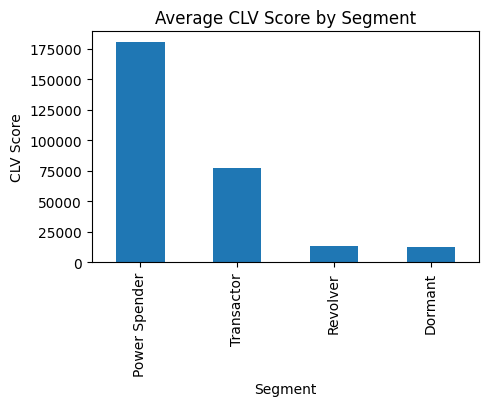

In [14]:
plt.figure(figsize=(5,3))

clv_segment.plot(kind="bar")

plt.title("Average CLV Score by Segment")
plt.xlabel("Segment")
plt.ylabel("CLV Score")

plt.show()

**Portfolio Yield Contribution**

In [15]:
yield_segment = df.groupby("Customer_Segment")["Portfolio_Yield_Proxy"].sum().sort_values(ascending=False)

print(yield_segment)

Customer_Segment
Dormant          6.420571e+06
Revolver         4.943481e+06
Transactor       7.928837e+04
Power Spender    2.934946e+04
Name: Portfolio_Yield_Proxy, dtype: float64


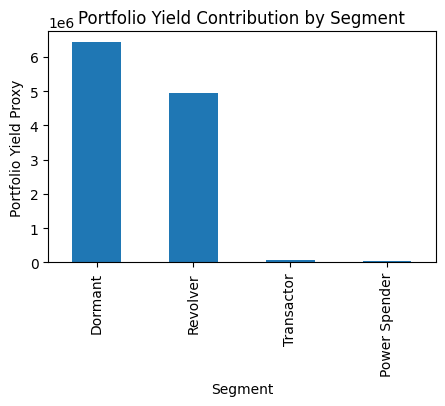

In [16]:
plt.figure(figsize=(5,3))

yield_segment.plot(kind="bar")

plt.title("Portfolio Yield Contribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Portfolio Yield Proxy")

plt.show()

# Key Findings

1. Customers with lower engagement and transaction velocity show higher churn tendencies

2. A small segment of customers contributes disproportionately to portfolio revenue

3. High CLV customers with declining activity represent the highest business risk

Conclusion:
The hypotheses are largely supported by observed behavioral patterns.


In [17]:
df.to_csv("../dataset/processed/credit_card_segmented.csv", index=False)

print("Segmented dataset saved successfully")

Segmented dataset saved successfully
